<a href="https://colab.research.google.com/github/Akspaks007/DL-Lab/blob/main/Exp_6/Exp_7_StockPriceLSTM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Data Loading and Preprocessing

In [ ]:
import yfinance as yf
import numpy as np
import csv
import matplotlib.pyplot as plt

ticker = "AAPL"
print(f"Downloading {ticker} data...")
df = yf.download(ticker, start="2020-01-01", end="2026-01-01", auto_adjust=False)
df.to_csv('yahoo_finance.csv')

def load_finance_data(file_path):
    prices = []
    with open(file_path, 'r') as f:
        reader = csv.reader(f)

        for row in reader:
            try:
                val = float(row[5])
                prices.append(val)
            except (ValueError, IndexError):
                continue

    return np.array(prices).reshape(-1, 1)

raw_data = load_finance_data('yahoo_finance.csv')
if len(raw_data) == 0:
    raise ValueError("No data loaded. Check the CSV structure.")

min_val, max_val = np.min(raw_data), np.max(raw_data)
scaled_data = (raw_data - min_val) / (max_val - min_val)

def create_sequences(data, window_size):
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data[i:i+window_size])
        y.append(data[i+window_size])
    return np.array(X), np.array(y)

print(f"Successfully preprocessed {len(scaled_data)} days of data.")

[*********************100%***********************]  1 of 1 completed

Successfully preprocessed 1508 days of data.


LSTM Architecture

In [ ]:
class NumPyLSTM:
    def __init__(self, input_dim, hidden_dim, lr=0.01):
        self.lr, self.h_dim = lr, hidden_dim
        concat_dim = input_dim + hidden_dim

        self.W = np.random.randn(4 * hidden_dim, concat_dim) * np.sqrt(2/concat_dim)
        self.b = np.zeros((4 * hidden_dim, 1))
        self.Wy = np.random.randn(1, hidden_dim) * np.sqrt(2/hidden_dim)
        self.by = np.zeros((1, 1))

    def sigmoid(self, x): return 1 / (1 + np.exp(-x))
    def tanh(self, x): return np.tanh(x)

    def forward(self, x_seq):
        self.states = {-1: (np.zeros((self.h_dim, 1)), np.zeros((self.h_dim, 1)))}
        self.caches = {}

        for t, xt in enumerate(x_seq):
            h_prev, c_prev = self.states[t-1]
            concat = np.vstack((h_prev, xt.reshape(-1, 1)))

            gates = np.dot(self.W, concat) + self.b
            i, f, o, g = np.split(gates, 4)

            i, f, o = self.sigmoid(i), self.sigmoid(f), self.sigmoid(o)
            g = self.tanh(g)

            c_next = f * c_prev + i * g
            h_next = o * self.tanh(c_next)

            self.states[t] = (h_next, c_next)
            self.caches[t] = (i, f, o, g, concat, c_prev)

        return np.dot(self.Wy, self.states[len(x_seq)-1][0]) + self.by

    def backward(self, x_seq, target, pred):
        T = len(x_seq)
        dy = pred - target
        dWy = np.dot(dy, self.states[T-1][0].T)
        dby = dy

        dh_next = np.dot(self.Wy.T, dy)
        dc_next = np.zeros((self.h_dim, 1))
        dW, db = np.zeros_like(self.W), np.zeros_like(self.b)

        for t in reversed(range(T)):
            i, f, o, g, concat, c_prev = self.caches[t]
            h_curr, c_curr = self.states[t]

            do = dh_next * self.tanh(c_curr) * (o * (1 - o))
            dc = dc_next + (dh_next * o * (1 - np.tanh(c_curr)**2))
            dg = dc * i * (1 - g**2)
            di = dc * g * (i * (1 - i))
            df = dc * c_prev * (f * (1 - f))

            dgates = np.vstack((di, df, do, dg))
            dW += np.dot(dgates, concat.T)
            db += dgates

            dh_next = np.dot(self.W[:, :self.h_dim].T, dgates)
            dc_next = f * dc

        for p, g in zip([self.W, self.b, self.Wy, self.by], [dW, db, dWy, dby]):
            p -= self.lr * np.clip(g, -1, 1)

Implementation


--- Training Window Size: 5 ---
Epoch 1/10 | Avg MSE: 0.056463
Epoch 2/10 | Avg MSE: 0.020956
Epoch 3/10 | Avg MSE: 0.017860
Epoch 4/10 | Avg MSE: 0.017947
Epoch 5/10 | Avg MSE: 0.017939
Epoch 6/10 | Avg MSE: 0.017717
Epoch 7/10 | Avg MSE: 0.017393
Epoch 8/10 | Avg MSE: 0.017032
Epoch 9/10 | Avg MSE: 0.016663
Epoch 10/10 | Avg MSE: 0.016296

--- Training Window Size: 20 ---
Epoch 1/10 | Avg MSE: 0.045618
Epoch 2/10 | Avg MSE: 0.016609
Epoch 3/10 | Avg MSE: 0.012895
Epoch 4/10 | Avg MSE: 0.012636
Epoch 5/10 | Avg MSE: 0.012600
Epoch 6/10 | Avg MSE: 0.012448
Epoch 7/10 | Avg MSE: 0.012214
Epoch 8/10 | Avg MSE: 0.011944
Epoch 9/10 | Avg MSE: 0.011660
Epoch 10/10 | Avg MSE: 0.011373


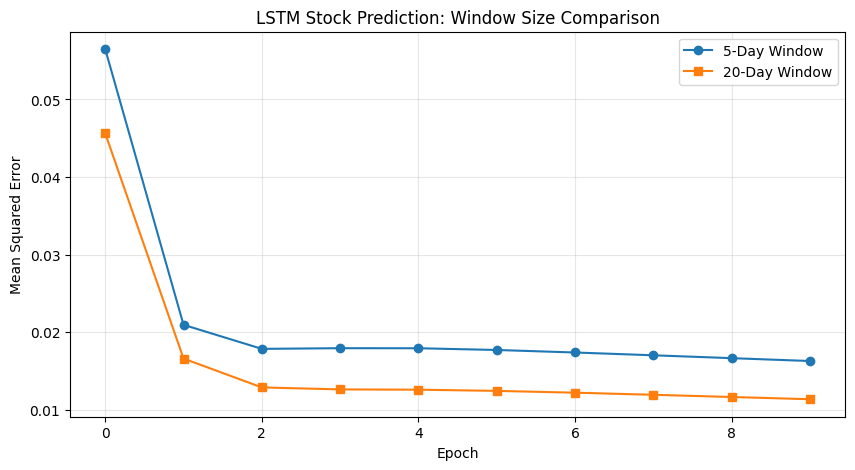

In [ ]:
def train_lstm_experiment(window_size, epochs=10):
    X, y = create_sequences(scaled_data, window_size)
    model = NumPyLSTM(input_dim=1, hidden_dim=32, lr=0.001)
    history = []

    print(f"\n--- Training Window Size: {window_size} ---")
    for epoch in range(epochs):
        epoch_loss = 0
        num_samples = min(500, len(X))
        for i in range(num_samples):
            pred = model.forward(X[i])
            loss = (pred - y[i])**2
            model.backward(X[i], y[i], pred)
            epoch_loss += loss

        avg_loss = (epoch_loss / num_samples)[0][0]
        history.append(avg_loss)
        print(f"Epoch {epoch+1}/{epochs} | Avg MSE: {avg_loss:.6f}")
    return history

hist_w5 = train_lstm_experiment(5)
hist_w20 = train_lstm_experiment(20)

plt.figure(figsize=(10, 5))
plt.plot(hist_w5, label='5-Day Window', marker='o')
plt.plot(hist_w20, label='20-Day Window', marker='s')
plt.title('LSTM Stock Prediction: Window Size Comparison')
plt.xlabel('Epoch')
plt.ylabel('Mean Squared Error')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()